# 6. Statistical and mechanistic analysis

Versione pulita: cartelle ordinate sotto `reports/04_mechanistic_analysis`. I plot finali sono separati dagli output esplorativi, perché apparentemente anche i file PNG hanno bisogno di una gerarchia sociale.

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists() or (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Project root not found. Run the notebook from inside the project repository.")

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

def report_dir(root: Path, analysis_name: str, subfolder: str | None = None) -> Path:
    base = root / "reports" / analysis_name
    return ensure_dir(base if subfolder is None else base / subfolder)

ROOT = find_project_root()
print("ROOT:", ROOT)


ROOT: /home/eleonorab/repository/convective_cooling


In [2]:
import pandas as pd
import statsmodels.formula.api as smf
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from scipy.signal import savgol_filter
from scipy.stats import linregress

ROOT = find_project_root()

df = pd.read_csv(ROOT / "data" / "processed" / "features" / "phase_features_long.csv")

# scegli segnale
df_sig = df[df["signal"] == "t_dorsal"].copy()

# modello
model = smf.mixedlm(
    "delta_mean_from_baseline ~ condition * phase",
    data=df_sig,
    groups=df_sig["subject_id"]
)

result = model.fit()
print(result.summary())

                        Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      delta_mean_from_baseline
No. Observations:      132          Method:                  REML                    
No. Groups:            8            Scale:                   0.3661                  
Min. group size:       6            Log-Likelihood:          -129.3109               
Max. group size:       18           Converged:               Yes                     
Mean group size:       16.5                                                          
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  -0.123    0.253 -0.485 0.628 -0.618  0.373
condition[T.wind_high]                     -0.074    0.314 -0.235 0.814 -0.690

In [3]:
# this part is to evaluate the model fit and the indices, but it's not fully implemented yet

DATA_PATH = ROOT / "data" / "processed" / "features" / "analysis_dataset_with_tsk.csv"
OUTPUT_DIR = report_dir(ROOT, "04_mechanistic_analysis", "convective_indices")

SUBJECT_ID = None

PHASE = "walk_mod_1"

CONDITIONS = ["no_wind", "wind_high"]

TIME_COL = "elapsed_seconds"
SUBJECT_COL = "subject_id"
CONDITION_COL = "condition"
PHASE_COL = "phase"

CONDITION_COLORS = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}

T_DORSAL_COL = "t_dorsal"
T_MICRO_COL = "t_microclimateback"

PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]

PHASE_LABELS = {
    "standing_1": "Phase 1",
    "walk_low_1": "Phase 2",
    "walk_mod_1": "Phase 3",
    "walk_low_2": "Phase 4",
    "walk_mod_2": "Phase 5",
    "standing_2": "Phase 6",
}

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]

# Savitzky-Golay smoothing settings
WINDOW_LENGTH = 11
POLYORDER = 2

# Avoid unstable ACI when the thermal gradient is too small
DELTAT_MIN_THRESHOLD = 0.01

df = pd.read_csv(DATA_PATH)

def ensure_output_dir(path):
    os.makedirs(path, exist_ok=True)


def choose_subject(df, subject_col, subject_id=None):
    if subject_id is not None:
        return subject_id

    counts = (
        df[df[PHASE_COL] == PHASE]
        .groupby([subject_col, CONDITION_COL])
        .size()
        .reset_index(name="n_rows")
    )

    valid_subjects = []

    for subj in counts[subject_col].unique():
        sub_counts = counts[counts[subject_col] == subj]

        ok = True
        for cond in CONDITIONS:
            n = sub_counts.loc[sub_counts[CONDITION_COL] == cond, "n_rows"]
            if len(n) == 0 or n.iloc[0] < 3:
                ok = False

        if ok:
            valid_subjects.append(subj)

    if len(valid_subjects) == 0:
        raise ValueError(
            "No subject has at least 3 rows for all selected conditions "
            f"in phase {PHASE}."
        )

    return sorted(valid_subjects)[0]


def check_required_columns(df, required_cols):
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns in dataset: {missing}\n"
            f"Available columns are:\n{list(df.columns)}"
        )


def prepare_condition_data(df, subject_id, condition, phase):
    data = df[
        (df[SUBJECT_COL] == subject_id) &
        (df[CONDITION_COL] == condition) &
        (df[PHASE_COL] == phase)
    ].copy()

    if data.empty:
        raise ValueError(
            f"No data found for subject={subject_id}, "
            f"condition={condition}, phase={phase}"
        )

    data = data.sort_values(TIME_COL).reset_index(drop=True)

    cols = [
        TIME_COL,
        SUBJECT_COL,
        CONDITION_COL,
        PHASE_COL,
        T_DORSAL_COL,
        T_MICRO_COL
    ]

    data = data[cols].copy()

    # Convert signals to numeric
    data[TIME_COL] = pd.to_numeric(data[TIME_COL], errors="coerce")
    data[T_DORSAL_COL] = pd.to_numeric(data[T_DORSAL_COL], errors="coerce")
    data[T_MICRO_COL] = pd.to_numeric(data[T_MICRO_COL], errors="coerce")

    data = data.dropna(subset=[TIME_COL])
    data = data.sort_values(TIME_COL)

    # Average duplicated timestamps, if present
    data_interp = (
        data.groupby(TIME_COL, as_index=False)
        .agg({
            SUBJECT_COL: "first",
            CONDITION_COL: "first",
            PHASE_COL: "first",
            T_DORSAL_COL: "mean",
            T_MICRO_COL: "mean"
        })
    )

    # Interpolate the two signals independently over time
    data_interp[T_DORSAL_COL] = data_interp[T_DORSAL_COL].interpolate(
        method="linear",
        limit_direction="both"
    )

    data_interp[T_MICRO_COL] = data_interp[T_MICRO_COL].interpolate(
        method="linear",
        limit_direction="both"
    )

    # Now remove only rows where interpolation still failed
    data_interp = data_interp.dropna(subset=[T_DORSAL_COL, T_MICRO_COL])

    if len(data_interp) < 3:
        raise ValueError(
            f"Not enough aligned/interpolated points for subject={subject_id}, "
            f"condition={condition}, phase={phase}. "
            f"Rows after interpolation: {len(data_interp)}"
        )

    return data_interp


def smooth_signal(y, window_length=11, polyorder=2):
    y = np.asarray(y, dtype=float)

    if len(y) < 5:
        return y


    window = min(window_length, len(y))

    if window % 2 == 0:
        window -= 1

    if window <= polyorder:
        return y

    return savgol_filter(y, window_length=window, polyorder=polyorder)


def compute_convective_indices(data):
    data = data.copy()
    data = data.sort_values(TIME_COL).reset_index(drop=True)

    condition_name = data[CONDITION_COL].iloc[0] if len(data) > 0 else "unknown"

    data = data.drop_duplicates(subset=TIME_COL)

    if len(data) < 3:
        raise ValueError(
            f"Not enough valid data points for condition={condition_name}. "
            f"Only {len(data)} rows available."
        )

    t_sec = data[TIME_COL].values.astype(float)
    t_dorsal = data[T_DORSAL_COL].values.astype(float)
    t_micro = data[T_MICRO_COL].values.astype(float)

    t_dorsal_smooth = smooth_signal(
        t_dorsal,
        window_length=WINDOW_LENGTH,
        polyorder=POLYORDER
    )

    deltaT_loc = t_dorsal_smooth - t_micro

    dTdt = np.gradient(t_dorsal_smooth, t_sec)

    CR = -dTdt

    ACI = np.full_like(CR, np.nan, dtype=float)

    valid = np.abs(deltaT_loc) >= DELTAT_MIN_THRESHOLD
    ACI[valid] = CR[valid] / deltaT_loc[valid]

    data["t_dorsal_smooth"] = t_dorsal_smooth
    data["deltaT_loc"] = deltaT_loc
    data["dTdt_C_per_s"] = dTdt
    data["CR_C_per_s"] = CR
    data["ACI_1_per_s"] = ACI
    data["valid_ACI"] = valid

    print(condition_name, "- aligned rows:", len(data))

    return data

def fit_cr_vs_deltaT(data):
    valid = (
        data["valid_ACI"] &
        np.isfinite(data["CR_C_per_s"]) &
        np.isfinite(data["deltaT_loc"])
    )

    x = data.loc[valid, "deltaT_loc"].values
    y = data.loc[valid, "CR_C_per_s"].values

    if len(x) < 3:
        return None

    result = linregress(x, y)

    return {
        "k_c_slope_1_per_s": result.slope,
        "intercept_C_per_s": result.intercept,
        "r_value": result.rvalue,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "std_err": result.stderr,
        "n_points": len(x)
    }
    
def fit_phase_transition(data, transition_window_s=180):
    data = data.copy()
    data = data.sort_values(TIME_COL).reset_index(drop=True)

    # Use only the first part of the phase
    t0_abs = data[TIME_COL].min()
    data = data[data[TIME_COL] <= t0_abs + transition_window_s].copy()

    if len(data) < 5:
        return None

    # Local time from phase start
    t = data[TIME_COL].values.astype(float)
    t = t - t.min()

    T = data[T_DORSAL_COL].values.astype(float)

    # Smooth before fitting
    T_smooth = smooth_signal(
        T,
        window_length=WINDOW_LENGTH,
        polyorder=POLYORDER
    )

    # Initial guesses
    T0_guess = T_smooth[0]
    T_eq_guess = T_smooth[-1]
    k_guess = 1 / 120  # about 2 min time constant

    try:
        popt, pcov = curve_fit(
            exponential_relaxation,
            t,
            T_smooth,
            p0=[T_eq_guess, T0_guess, k_guess],
            bounds=(
                [20, 20, 0],
                [45, 45, 1]
            ),
            maxfev=10000
        )

        T_eq, T0, k = popt

        T_pred = exponential_relaxation(t, T_eq, T0, k)

        ss_res = np.sum((T_smooth - T_pred) ** 2)
        ss_tot = np.sum((T_smooth - np.mean(T_smooth)) ** 2)

        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        return {
            "T_eq_transition": T_eq,
            "T0_transition": T0,
            "k_transition_1_per_s": k,
            "tau_transition_s": 1 / k if k > 0 else np.nan,
            "r_squared_transition": r_squared,
            "n_points_transition": len(data)
        }

    except Exception as e:
        return {
            "T_eq_transition": np.nan,
            "T0_transition": np.nan,
            "k_transition_1_per_s": np.nan,
            "tau_transition_s": np.nan,
            "r_squared_transition": np.nan,
            "n_points_transition": len(data),
            "transition_fit_error": str(e)
        }
        
def summarize_one_group(data, subject_id, condition, phase):
    data = compute_convective_indices(data)

    # Intra-phase model:
    # CR = k_c * deltaT_loc + b
    fit = fit_cr_vs_deltaT(data)

    # Phase-transition model:
    # T(t) = T_eq + (T0 - T_eq) exp(-k t)
    transition_fit = fit_phase_transition(data)

    valid = data["valid_ACI"] & data["ACI_1_per_s"].notna()

    summary = {
        "subject_id": subject_id,
        "condition": condition,
        "phase": phase,

        # Descriptive counts
        "n_points": len(data),
        "n_valid_ACI": valid.sum(),

        # Derived physical quantities
        "mean_deltaT_loc": data["deltaT_loc"].mean(),
        "median_deltaT_loc": data["deltaT_loc"].median(),

        "mean_CR_C_per_s": data["CR_C_per_s"].mean(),
        "median_CR_C_per_s": data["CR_C_per_s"].median(),

        "mean_ACI_1_per_s": data.loc[valid, "ACI_1_per_s"].mean(),
        "median_ACI_1_per_s": data.loc[valid, "ACI_1_per_s"].median(),
        "std_ACI_1_per_s": data.loc[valid, "ACI_1_per_s"].std(),
    }

    # Add intra-phase fit
    if fit is not None:
        summary.update(fit)
    else:
        summary.update({
            "k_c_slope_1_per_s": np.nan,
            "intercept_C_per_s": np.nan,
            "r_value": np.nan,
            "r_squared": np.nan,
            "p_value": np.nan,
            "std_err": np.nan,
            "n_points_fit": 0
        })

    # Add transition fit
    if transition_fit is not None:
        summary.update(transition_fit)
    else:
        summary.update({
            "T_eq_transition": np.nan,
            "T0_transition": np.nan,
            "k_transition_1_per_s": np.nan,
            "tau_transition_s": np.nan,
            "r_squared_transition": np.nan,
            "n_points_transition": 0
        })

    return summary, data

def run_all_subjects():
    ensure_output_dir(OUTPUT_DIR)

    df = pd.read_csv(DATA_PATH)
    df.columns = df.columns.str.strip()

    required_cols = [
        TIME_COL,
        SUBJECT_COL,
        CONDITION_COL,
        PHASE_COL,
        T_DORSAL_COL,
        T_MICRO_COL
    ]

    check_required_columns(df, required_cols)

    summaries = []
    all_time_series = []

    subjects = sorted(df[SUBJECT_COL].dropna().unique())
    conditions = sorted(df[CONDITION_COL].dropna().unique())
    phases = sorted(df[PHASE_COL].dropna().unique())

    print("Subjects:", subjects)
    print("Conditions:", conditions)
    print("Phases:", phases)

    for subject_id in subjects:
        for condition in conditions:
            for phase in phases:
                subset = df[
                    (df[SUBJECT_COL] == subject_id) &
                    (df[CONDITION_COL] == condition) &
                    (df[PHASE_COL] == phase)
                ].copy()

                if subset.empty:
                    continue

                try:
                    data = prepare_condition_data(
                        df=df,
                        subject_id=subject_id,
                        condition=condition,
                        phase=phase
                    )

                    summary, data_indices = summarize_one_group(
                        data=data,
                        subject_id=subject_id,
                        condition=condition,
                        phase=phase
                    )

                    summaries.append(summary)
                    all_time_series.append(data_indices)

                except Exception as e:
                    print(
                        f"Skipping subject={subject_id}, "
                        f"condition={condition}, phase={phase}. "
                        f"Reason: {e}"
                    )

    summary_df = pd.DataFrame(summaries)
    # ============================================================
    # TRANSITION COEFFICIENT k ANALYSIS
    # T(t) = T_eq + (T0 - T_eq) exp(-k t)
    # ============================================================
    
    TRANSITION_DIR = ROOT / "reports" / "06_statistics" / "paper_figures"
    TRANSITION_DIR.mkdir(parents=True, exist_ok=True)
    
    transition_df = summary_df.copy()
    
    transition_cols = [
        "k_transition_1_per_s",
        "tau_transition_s",
        "r_squared_transition",
    ]
    
    for col in transition_cols:
        transition_df[col] = pd.to_numeric(transition_df[col], errors="coerce")
    
    transition_df = transition_df.dropna(
        subset=["k_transition_1_per_s", "r_squared_transition"]
    ).copy()
    
    transition_df = transition_df[
        transition_df["k_transition_1_per_s"] > 0
    ].copy()
    
    transition_df["phase"] = pd.Categorical(
        transition_df["phase"],
        categories=PHASE_ORDER,
        ordered=True,
    )
    
    transition_df["condition"] = pd.Categorical(
        transition_df["condition"],
        categories=CONDITION_ORDER,
        ordered=True,
    )
    
    time_series_df = pd.concat(all_time_series, ignore_index=True)

    summary_path = os.path.join(
        OUTPUT_DIR,
        "convective_indices_subject_phase_summary.csv"
    )

    time_series_path = os.path.join(
        OUTPUT_DIR,
        "convective_indices_all_timeseries.csv"
    )

    summary_df.to_csv(summary_path, index=False)
    time_series_df.to_csv(time_series_path, index=False)

    print("\nSaved:")
    print(summary_path)
    print(time_series_path)

    return summary_df, time_series_df

def plot_temperature_and_gradient(all_data, output_path):
    plt.figure(figsize=(10, 6))

    for condition, data in all_data.items():
        plt.plot(
            data[TIME_COL],
            data["t_dorsal_smooth"],
            label=f"{condition} - T dorsal"
        )
        plt.plot(
            data[TIME_COL],
            data[T_MICRO_COL],
            linestyle="--",
            label=f"{condition} - T microclimate"
        )

    plt.xlabel("Elapsed time [min]")
    plt.ylabel("Temperature [°C]")
    plt.title("Dorsal skin and microclimate temperature")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def plot_deltaT(all_data, output_path):
    plt.figure(figsize=(10, 5))

    for condition, data in all_data.items():
        plt.plot(
            data[TIME_COL],
            data["deltaT_loc"],
            label=condition
        )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Elapsed time [s]")
    plt.ylabel(r"$\Delta T_{loc}$ [°C]")
    plt.title("Local thermal driving force")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def plot_cr_vs_deltaT(all_data, fit_results, output_path):
    plt.figure(figsize=(7, 6))

    for condition, data in all_data.items():
        valid = data["valid_ACI"]

        x = data.loc[valid, "deltaT_loc"]
        y = data.loc[valid, "CR_C_per_s"]

        plt.scatter(x, y, label=condition, alpha=0.7)

        fit = fit_results.get(condition)

        if fit is not None:
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = (
                fit["k_c_slope_1_per_s"] * x_fit +
                fit["intercept_C_per_s"]
            )
            plt.plot(x_fit, y_fit)

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel(r"$\Delta T_{loc}$ [°C]")
    plt.ylabel("Cooling Rate [°C/s]")
    plt.title(r"Cooling Rate vs local thermal driving force")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def plot_aci_time_series(all_data, output_path):
    plt.figure(figsize=(10, 5))

    for condition, data in all_data.items():
        plt.plot(
            data[TIME_COL],
            data["ACI_1_per_s"],
            label=condition
        )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Elapsed time [min]")
    plt.ylabel("ACI [1/s]")
    plt.title("Apparent Convective Index over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()



In [4]:
# ------------------------------------------------------------
# Prepare transition dataframe
# ------------------------------------------------------------

TRANSITION_DIR = ROOT / "reports" / "06_statistics" / "paper_figures"
TRANSITION_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_DIR = ROOT / "data" / "processed" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

if "summary_df" not in globals():
    summary_df, time_series_df = run_all_subjects()

transition_df = summary_df.copy()

required_transition_cols = [
    "k_transition_1_per_s",
    "tau_transition_s",
    "r_squared_transition",
    "phase",
    "condition",
    "subject_id",
]

missing = [col for col in required_transition_cols if col not in transition_df.columns]

if missing:
    raise ValueError(
        f"Missing columns in summary_df: {missing}\n"
        f"Available columns are:\n{list(summary_df.columns)}"
    )

for col in [
    "k_transition_1_per_s",
    "tau_transition_s",
    "r_squared_transition",
]:
    transition_df[col] = pd.to_numeric(transition_df[col], errors="coerce")

transition_df = transition_df.dropna(
    subset=["k_transition_1_per_s", "r_squared_transition"]
).copy()

transition_df = transition_df[
    transition_df["k_transition_1_per_s"] > 0
].copy()

transition_df["phase"] = pd.Categorical(
    transition_df["phase"],
    categories=PHASE_ORDER,
    ordered=True,
)

transition_df["condition"] = pd.Categorical(
    transition_df["condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

print("transition_df shape:", transition_df.shape)
display(transition_df.head())

Subjects: ['tester_01', 'tester_02', 'tester_03', 'tester_04', 'tester_05', 'tester_06', 'tester_07', 'tester_08']
Conditions: ['no_wind', 'wind_high', 'wind_low']
Phases: ['standing_1', 'standing_2', 'walk_low_1', 'walk_low_2', 'walk_mod_1', 'walk_mod_2']
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
wind_high - aligned rows: 300
wind_high - aligned row

,subject_id,condition,phase,n_points,n_valid_ACI,mean_deltaT_loc,median_deltaT_loc,mean_CR_C_per_s,median_CR_C_per_s,mean_ACI_1_per_s,...,r_squared,p_value,std_err,T_eq_transition,T0_transition,k_transition_1_per_s,tau_transition_s,r_squared_transition,n_points_transition,transition_fit_error


Saved: /home/eleonorab/repository/convective_cooling/data/processed/features/transition_k_summary.csv


,phase,condition,n,mean_k,median_k,sd_k,mean_tau,median_tau,mean_r2,median_r2


,n,mean_k,median_k,sd_k,mean_tau,median_tau,mean_r2,median_r2
phase,,,,,,,,


,count,sum,mean
phase,,,


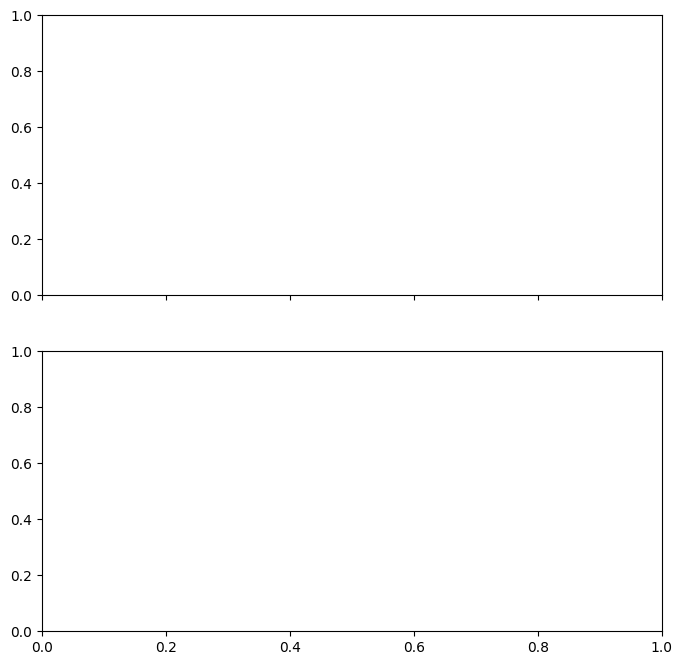

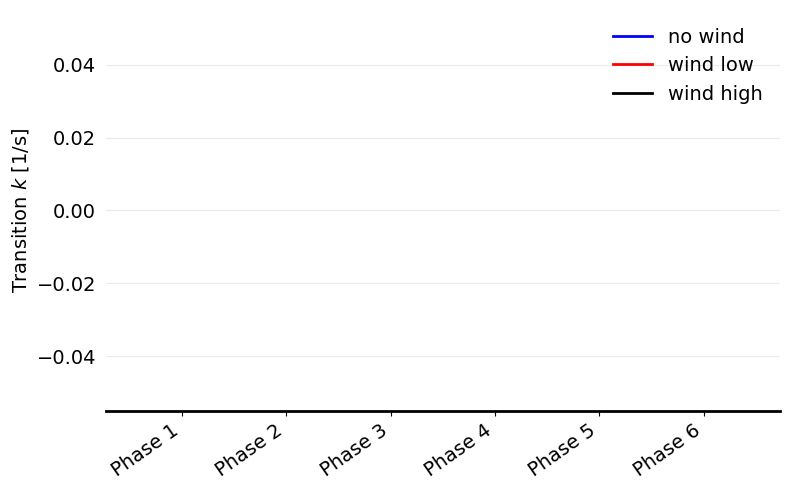

Saved: /home/eleonorab/repository/convective_cooling/reports/06_statistics/paper_figures/transition_k_by_phase_condition.png


In [5]:
from matplotlib.ticker import LogLocator

CONDITION_LABELS = {
    "no_wind": "no wind",
    "wind_low": "wind low",
    "wind_high": "wind high",
}

transition_summary = (
    transition_df.groupby(["phase", "condition"], observed=True).agg(
        n=("k_transition_1_per_s", "count"),
        mean_k=("k_transition_1_per_s", "mean"),
        median_k=("k_transition_1_per_s", "median"),
        sd_k=("k_transition_1_per_s", "std"),
        mean_tau=("tau_transition_s", "mean"),
        median_tau=("tau_transition_s", "median"),
        mean_r2=("r_squared_transition", "mean"),
        median_r2=("r_squared_transition", "median"),
    )
    .reset_index()
)

transition_summary_path = (
    ROOT / "data" / "processed" / "features" / "transition_k_summary.csv"
)

transition_summary.to_csv(transition_summary_path, index=False)

print(f"Saved: {transition_summary_path}")
display(transition_summary)


transition_phase_summary = (
    transition_df.groupby("phase", observed=True).agg(
        n=("k_transition_1_per_s", "count"),
        mean_k=("k_transition_1_per_s", "mean"),
        median_k=("k_transition_1_per_s", "median"),
        sd_k=("k_transition_1_per_s", "std"),
        mean_tau=("tau_transition_s", "mean"),
        median_tau=("tau_transition_s", "median"),
        mean_r2=("r_squared_transition", "mean"),
        median_r2=("r_squared_transition", "median"),
    )
)

display(transition_phase_summary)


transition_df["good_transition_fit"] = transition_df["r_squared_transition"] > 0.50

transition_good_fit = (
    transition_df.groupby("phase", observed=True)["good_transition_fit"].agg(["count", "sum", "mean"])
)

display(transition_good_fit)

# ------------------------------------------------------------
# Transition k and R2 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 8),
    sharex=True,
)

metrics = [
    (
        "k_transition_1_per_s",
        "(a) Transition coefficient",
        r"Transition $k$ [1/s]",
    ),
    (
        "r_squared_transition",
        "(b) Transition model goodness-of-fit",
        r"$R^2$ [-]",
    ),
]

x_base = np.arange(len(PHASE_ORDER))
width = 0.23

# ------------------------------------------------------------
# Transition coefficient k only
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5)
)

x_base = np.arange(len(PHASE_ORDER))
width = 0.23

for i, condition in enumerate(CONDITION_ORDER):

    values_by_phase = []

    for phase in PHASE_ORDER:

        values = (
            transition_df[
                (transition_df["condition"] == condition)
                & (transition_df["phase"] == phase)
            ]["k_transition_1_per_s"]
            .dropna()
            .to_numpy()
        )

        values_by_phase.append(values)

    positions = x_base + (i - 1) * width

    bp = ax.boxplot(
        values_by_phase,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        showfliers=True,
        medianprops={
            "color": "black",
            "linewidth": 1.8,
        },
        boxprops={
            "facecolor": "white",
            "edgecolor": CONDITION_COLORS[condition],
            "linewidth": 1.5,
        },
        whiskerprops={
            "color": CONDITION_COLORS[condition],
            "linewidth": 1.2,
        },
        capprops={
            "color": CONDITION_COLORS[condition],
            "linewidth": 1.2,
        },
        flierprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": CONDITION_COLORS[condition],
            "markersize": 4,
            "alpha": 0.8,
        },
    )

    ax.plot(
        [],
        [],
        color=CONDITION_COLORS[condition],
        label=CONDITION_LABELS[condition],
        linewidth=2,
    )

ax.set_ylabel(
    r"Transition $k$ [1/s]",
    fontsize=14,
)

ax.set_xticks(x_base)

ax.set_xticklabels(
    [PHASE_LABELS[p] for p in PHASE_ORDER],
    rotation=35,
    ha="right",
    fontsize=14,
)

ax.tick_params(
    axis="y",
    labelsize=14,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_linewidth(2.0)

ax.yaxis.set_ticks_position("none")

ax.legend(
    frameon=False,
    fontsize=14,
    loc="best",
)

fig.tight_layout()

png_path = TRANSITION_DIR / "transition_k_by_phase_condition.png"

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()

print(f"Saved: {png_path}")

ax.set_ylabel(
    r"Transition $k$ [1/s]",
    fontsize=14,
)

ax.set_yscale("log")

ax.yaxis.set_major_locator(
    LogLocator(base=10)
)

In [6]:
# ------------------------------------------------------------
# Forest plot of MixedLM coefficients
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FOREST_DIR = ROOT / "reports" / "06_statistics" / "paper_figures"
FOREST_DIR.mkdir(parents=True, exist_ok=True)

def make_interaction_forest_plot(
    result,
    output_dir: Path,
    filename: str = "mixedlm_coefficients_forest_plot.png",
):
    params = result.params.copy()
    conf = result.conf_int()
    pvalues = result.pvalues.copy()

    coef_df = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "ci_low": conf.iloc[:, 0].values,
        "ci_high": conf.iloc[:, 1].values,
        "pvalue": pvalues.values,
    })

    coef_df = coef_df[
        coef_df["term"].str.contains("condition", regex=False)
        & coef_df["term"].str.contains("phase", regex=False)
        & coef_df["term"].str.contains(":", regex=False)
    ].copy()

    coef_df["significant"] = coef_df["pvalue"] < 0.05

    phase_order = {
        "walk_low_1": 1,
        "walk_mod_1": 2,
        "walk_low_2": 3,
        "walk_mod_2": 4,
        "standing_2": 5,
    }

    condition_order = {
        "wind_low": 1,
        "wind_high": 2,
    }

    coef_df["condition_clean"] = (
        coef_df["term"]
        .str.extract(r"condition\[T\.(.*?)\]")[0]
    )

    coef_df["phase_clean"] = (
        coef_df["term"]
        .str.extract(r"phase\[T\.(.*?)\]")[0]
    )

    coef_df["phase_order"] = coef_df["phase_clean"].map(phase_order)
    coef_df["condition_order"] = coef_df["condition_clean"].map(condition_order)

    coef_df = coef_df.sort_values(
        ["phase_order", "condition_order"]
    ).reset_index(drop=True)

    coef_df["label"] = (
        coef_df["condition_clean"].str.replace("_", " ", regex=False)
        + " × "
        + coef_df["phase_clean"].str.replace("_", " ", regex=False)
    )

    y_pos = np.arange(len(coef_df))[::-1]

    fig, ax = plt.subplots(figsize=(12, max(6, 0.45 * len(coef_df))))

    colors = coef_df["significant"].map({
        True: "red",
        False: "blue",
    })

    sizes = np.where(coef_df["significant"], 70, 45)

    ax.errorbar(
        coef_df["coef"],
        y_pos,
        xerr=[
            coef_df["coef"] - coef_df["ci_low"],
            coef_df["ci_high"] - coef_df["coef"],
        ],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=3,
        zorder=2,
    )

    ax.scatter(
        coef_df["coef"],
        y_pos,
        c=colors,
        s=sizes,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="gray")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(coef_df["label"], fontsize=14)

    ax.set_xlabel("Mixed-interaction coefficient", fontsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.yaxis.set_ticks_position("none")
    ax.spines["bottom"].set_linewidth(2.0)
    ax.grid(axis="x", alpha=0.25)

    sig_marker = plt.Line2D(
        [0], [0],
        marker="o",
        color="red",
        label="p < 0.05",
        linestyle="None",
        markersize=9,
    )

    ns_marker = plt.Line2D(
        [0], [0],
        marker="o",
        color="blue",
        markeredgecolor="black",
        label="p ≥ 0.05",
        linestyle="None",
        markersize=9,
    )

    ax.legend(
        handles=[sig_marker, ns_marker],
        frameon=False,
        loc="lower right",
    )

    fig.tight_layout()

    png_path = output_dir / filename

    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved: {png_path}")

    return coef_df

In [7]:
# ============================================================
# MAIN SCRIPT
# ============================================================

def main():
    ensure_output_dir(OUTPUT_DIR)

    df = pd.read_csv(DATA_PATH)

    required_cols = [
        TIME_COL,
        SUBJECT_COL,
        CONDITION_COL,
        PHASE_COL,
        T_DORSAL_COL,
        T_MICRO_COL
    ]

    check_required_columns(df, required_cols)

    subject_id = choose_subject(df, SUBJECT_COL, SUBJECT_ID)

    print("\nConvective indices example")
    print("\nRows available for selected phase:")
    print(
        df[df[PHASE_COL] == PHASE]
        .groupby([SUBJECT_COL, CONDITION_COL, PHASE_COL])
        .size()
        .reset_index(name="n_rows")
        .sort_values("n_rows", ascending=False)
    )
    print("--------------------------")
    print(f"Subject: {subject_id}")
    print(f"Phase: {PHASE}")
    print(f"Conditions: {CONDITIONS}")

    all_data = {}
    fit_results = {}

    for condition in CONDITIONS:
        data = prepare_condition_data(
            df=df,
            subject_id=subject_id,
            condition=condition,
            phase=PHASE
        )

        data = compute_convective_indices(data)

        all_data[condition] = data
        fit_results[condition] = fit_cr_vs_deltaT(data)

        output_csv = os.path.join(
            OUTPUT_DIR,
            f"convective_indices_{subject_id}_{condition}_{PHASE}.csv"
        )
        data.to_csv(output_csv, index=False)

    # Save plots
    plot_temperature_and_gradient(
        all_data,
        os.path.join(
            OUTPUT_DIR,
            f"temperature_microclimate_{subject_id}_{PHASE}.png"
        )
    )

    plot_deltaT(
        all_data,
        os.path.join(
            OUTPUT_DIR,
            f"deltaT_loc_{subject_id}_{PHASE}.png"
        )
    )

    plot_cr_vs_deltaT(
        all_data,
        fit_results,
        os.path.join(
            OUTPUT_DIR,
            f"CR_vs_deltaT_{subject_id}_{PHASE}.png"
        )
    )

    plot_aci_time_series(
        all_data,
        os.path.join(
            OUTPUT_DIR,
            f"ACI_timeseries_{subject_id}_{PHASE}.png"
        )
    )

    # Save fit summary
    fit_summary = []

    for condition, result in fit_results.items():
        if result is None:
            fit_summary.append({
                "subject": subject_id,
                "phase": PHASE,
                "k_c_slope_1_per_s": np.nan,
                "intercept_C_per_s": np.nan,
                "r_squared": np.nan,
                "p_value": np.nan,
                "n_points": 0
            })
        else:
            row = {
                "subject": subject_id,
                "phase": PHASE,
                "condition": condition
            }
            row.update(result)
            fit_summary.append(row)

    fit_summary_df = pd.DataFrame(fit_summary)

    fit_summary_path = os.path.join(
        OUTPUT_DIR,
        f"fit_summary_{subject_id}_{PHASE}.csv"
    )

    fit_summary_df.to_csv(fit_summary_path, index=False)

    print("\nFit summary:")
    print(fit_summary_df)

    print("\nFiles saved in:")
    print(OUTPUT_DIR)


#if __name__ == "__main__":
#    main()

In [8]:
def exponential_relaxation(t, T_eq, T0, k):
    return T_eq + (T0 - T_eq) * np.exp(-k * t)

def run_lmm_on_convective_indices(summary_df):
    import statsmodels.formula.api as smf

    outcomes = [
    "mean_ACI_1_per_s",
    "k_c_slope_1_per_s",
    "k_transition_1_per_s",
    "tau_transition_s",
    "T_eq_transition",
    "mean_CR_C_per_s",
    "mean_deltaT_loc"
    ]

    results = {}

    for outcome in outcomes:
        data = summary_df.dropna(subset=[outcome]).copy()

        if data.empty:
            print(f"\nSkipping {outcome}: no valid data.")
            continue

        print("\n" + "=" * 80)
        print(f"LMM for {outcome}")
        print("=" * 80)

        try:
            model = smf.mixedlm(
                f"{outcome} ~ condition * phase",
                data=data,
                groups=data["subject_id"]
            )
            result = model.fit(method="lbfgs")
            print(result.summary())
            results[outcome] = result

        except Exception as e:
            print(f"Full model failed for {outcome}: {e}")

            try:
                print(f"\nTrying reduced model for {outcome}...")
                model = smf.mixedlm(
                    f"{outcome} ~ condition + phase",
                    data=data,
                    groups=data["subject_id"]
                )
                result = model.fit(method="lbfgs")
                print(result.summary())
                results[outcome] = result

            except Exception as e2:
                print(f"Reduced model also failed for {outcome}: {e2}")

    return results

def plot_boxplot_by_condition(summary_df, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    variables = {
    "mean_ACI_1_per_s": "Mean ACI [1/s]",
    "k_c_slope_1_per_s": r"$k_c$ slope [1/s]",
    "k_transition_1_per_s": r"Transition $k$ [1/s]",
    "tau_transition_s": r"Transition time constant $\tau$ [s]",
    "T_eq_transition": r"Estimated $T_{eq}$ [°C]",
    "mean_CR_C_per_s": "Mean cooling rate [°C/s]",
    "mean_deltaT_loc": r"Mean $\Delta T_{loc}$ [°C]"
    }

    for var, ylabel in variables.items():
        if var not in summary_df.columns:
            print(f"Skipping {var}: column not found")
            continue

        plot_data = summary_df.dropna(subset=[var]).copy()

        if plot_data.empty:
            print(f"Skipping {var}: no valid data")
            continue

        conditions = sorted(plot_data["condition"].unique())
        values = [
            plot_data.loc[plot_data["condition"] == cond, var].values
            for cond in conditions
        ]

        plt.figure(figsize=(7, 5))
        plt.boxplot(values, labels=conditions, showmeans=True)

        plt.xlabel("Condition")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} by condition")
        plt.tight_layout()

        filename = f"boxplot_{var}_by_condition.png"
        plt.savefig(os.path.join(output_dir, filename), dpi=300)
        plt.close()


def plot_boxplot_by_condition_phase(summary_df, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    variables = {
        "mean_ACI_1_per_s": "Mean ACI [1/s]",
        "k_c_slope_1_per_s": r"$k_c$ slope [1/s]",
        "mean_CR_C_per_s": "Mean cooling rate [°C/s]",
        "mean_deltaT_loc": r"Mean $\Delta T_{loc}$ [°C]"
    }

    for var, ylabel in variables.items():
        if var not in summary_df.columns:
            print(f"Skipping {var}: column not found")
            continue

        plot_data = summary_df.dropna(subset=[var]).copy()

        if plot_data.empty:
            print(f"Skipping {var}: no valid data")
            continue

        phases = sorted(plot_data["phase"].unique())
        conditions = sorted(plot_data["condition"].unique())

        x_positions = []
        values = []
        labels = []

        pos = 1
        for phase in phases:
            for condition in conditions:
                subset = plot_data[
                    (plot_data["phase"] == phase) &
                    (plot_data["condition"] == condition)
                ][var].values

                if len(subset) > 0:
                    values.append(subset)
                    x_positions.append(pos)
                    labels.append(f"{phase}\n{condition}")
                    pos += 1

            pos += 1

        plt.figure(figsize=(14, 6))
        plt.boxplot(values, positions=x_positions, showmeans=True)

        plt.xticks(x_positions, labels, rotation=90)
        plt.xlabel("Phase and condition")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} by phase and condition")
        plt.tight_layout()

        filename = f"boxplot_{var}_by_condition_phase.png"
        plt.savefig(os.path.join(output_dir, filename), dpi=300)
        plt.close()


def plot_mean_bar_by_condition(summary_df, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    variables = {
        "mean_ACI_1_per_s": "Mean ACI [1/s]",
        "k_c_slope_1_per_s": r"$k_c$ slope [1/s]",
        "mean_CR_C_per_s": "Mean cooling rate [°C/s]",
        "mean_deltaT_loc": r"Mean $\Delta T_{loc}$ [°C]"
    }

    for var, ylabel in variables.items():
        if var not in summary_df.columns:
            continue

        stats = (
            summary_df
            .dropna(subset=[var])
            .groupby("condition")[var]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        if stats.empty:
            continue

        plt.figure(figsize=(7, 5))
        plt.bar(
            stats["condition"],
            stats["mean"],
            yerr=stats["std"],
            capsize=5
        )

        plt.xlabel("Condition")
        plt.ylabel(ylabel)
        plt.title(f"Mean {ylabel} by condition")
        plt.tight_layout()

        filename = f"bar_mean_{var}_by_condition.png"
        plt.savefig(os.path.join(output_dir, filename), dpi=300)
        plt.close()


def plot_time_series_mean_by_condition(time_series_df, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    variables = {
        "deltaT_loc": r"$\Delta T_{loc}$ [°C]",
        "CR_C_per_s": "Cooling rate [°C/s]",
        "ACI_1_per_s": "ACI [1/s]"
    }

    for var, ylabel in variables.items():
        if var not in time_series_df.columns:
            continue

        plot_data = time_series_df.dropna(subset=[var]).copy()

        if plot_data.empty:
            continue

        # Use elapsed minutes for nicer plots
        plot_data["elapsed_minutes_plot"] = plot_data["elapsed_seconds"] / 60

        # Bin time to avoid chaotic overplotting
        plot_data["time_bin_min"] = plot_data["elapsed_minutes_plot"].round(1)

        mean_ts = (
            plot_data
            .groupby(["condition", "time_bin_min"])[var]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        plt.figure(figsize=(10, 5))

        for condition in sorted(mean_ts["condition"].unique()):
            subset = mean_ts[mean_ts["condition"] == condition]

            plt.plot(
                subset["time_bin_min"],
                subset["mean"],
                label=condition
            )

        plt.xlabel("Elapsed time [min]")
        plt.ylabel(ylabel)
        plt.title(f"Mean time series of {ylabel} by condition")
        plt.legend()
        plt.tight_layout()

        filename = f"timeseries_mean_{var}_by_condition.png"
        plt.savefig(os.path.join(output_dir, filename), dpi=300)
        plt.close()

def run_all_convective_plots(summary_df, time_series_df, output_dir):
    plot_boxplot_by_condition(summary_df, output_dir)
    plot_boxplot_by_condition_phase(summary_df, output_dir)
    plot_mean_bar_by_condition(summary_df, output_dir)
    plot_time_series_mean_by_condition(time_series_df, output_dir)

    print("Plots saved in:")
    print(output_dir)


In [9]:
summary_df, time_series_df = run_all_subjects()
lmm_results = run_lmm_on_convective_indices(summary_df)

PLOT_DIR = OUTPUT_DIR / "summary_plots"

run_all_convective_plots(
    summary_df=summary_df,
    time_series_df=time_series_df,
    output_dir=PLOT_DIR
)

Subjects: ['tester_01', 'tester_02', 'tester_03', 'tester_04', 'tester_05', 'tester_06', 'tester_07', 'tester_08']
Conditions: ['no_wind', 'wind_high', 'wind_low']
Phases: ['standing_1', 'standing_2', 'walk_low_1', 'walk_low_2', 'walk_mod_1', 'walk_mod_2']
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
no_wind - aligned rows: 300
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_high - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
wind_low - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
no_wind - aligned rows: 360
wind_high - aligned rows: 300
wind_high - aligned row

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_

                        Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         T_eq_transition
No. Observations:          126             Method:                     REML           
No. Groups:                8               Scale:                      37.7395        
Min. group size:           6               Log-Likelihood:             -366.7598      
Max. group size:           18              Converged:                  Yes            
Mean group size:           15.8                                                       
--------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                  38.491    2.172 17.721 0.000  34.234 42.749
condition[T.wind_high]                     -2.106    3.180 -0.662 0.

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                        Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         mean_CR_C_per_s
No. Observations:         126             Method:                     REML           
No. Groups:               8               Scale:                      0.0000         
Min. group size:          6               Log-Likelihood:             565.4330       
Max. group size:          18              Converged:                  Yes            
Mean group size:          15.8                                                       
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  -0.001    0.000 -3.166 0.002 -0.002 -0.000
condition[T.wind_high]                     -0.000    0.001 -0.204 0.838 -0.001

/tmp/ipykernel_6233/1805698557.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=conditions, showmeans=True)
/tmp/ipykernel_6233/1805698557.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=conditions, showmeans=True)
/tmp/ipykernel_6233/1805698557.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=conditions, showmeans=True)
/tmp/ipykernel_6233/1805698557.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 

Plots saved in:
/home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/convective_indices/summary_plots


In [10]:
PAPER_PLOT_DIR = report_dir(ROOT, "04_mechanistic_analysis", "paper_figures")
ensure_dir(PAPER_PLOT_DIR)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]

PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_low_2",
    "walk_mod_1",
    "walk_mod_2",
    "standing_2",
]

PHASE_LABELS = {
    "standing_1": "Phase 1",
    "walk_low_1": "Phase 2",
    "walk_low_2": "Phase 3",
    "walk_mod_1": "Phase 4",
    "walk_mod_2": "Phase 5",
    "standing_2": "Phase 6",
}

CONDITION_LABELS = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}

CONDITION_COLORS = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}

def sem(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))


def add_protocol_background(ax):
    """
    Background phases based on your 60 min protocol:
    0-10 standing_1
    10-20 walk_low_1
    20-30 walk_high_1
    30-40 walk_low_2
    40-50 walk_high_2
    50-60 standing_2
    """
    phases = [
        (0, 10, "Phase 1"),
        (10, 20, "Phase 2"),
        (20, 30, "Phase 3"),
        (30, 40, "Phase 4"),
        (40, 50, "Phase 5"),
        (50, 60, "Phase 6"),
    ]

    for i, (start, end, label) in enumerate(phases):
        if i % 2 == 0:
            ax.axvspan(start, end, alpha=0.08)

        ax.axvline(start, linewidth=0.8, alpha=0.4)

        y_top = ax.get_ylim()[1]
        ax.text(
            (start + end) / 2,
            y_top,
            label,
            ha="center",
            va="top",
            fontsize=8,
            alpha=0.8,
        )

    ax.axvline(60, linewidth=0.8, alpha=0.4)


# ------------------------------------------------------------
# 1. Mean time series of Delta T_loc with SEM
# ------------------------------------------------------------

def plot_paper_timeseries_deltaT(time_series_df, output_dir):
    var = "deltaT_loc"

    plot_data = time_series_df.dropna(subset=[var]).copy()
    plot_data["elapsed_minutes"] = plot_data["elapsed_seconds"] / 60
    plot_data["time_bin_min"] = plot_data["elapsed_minutes"].round(1)

    stats = (
        plot_data
        .groupby(["condition", "time_bin_min"])[var]
        .agg(mean="mean", sem=sem, count="count")
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(15, 5))

    for condition in CONDITION_ORDER:
        subset = stats[stats["condition"] == condition].sort_values("time_bin_min")

        if subset.empty:
            continue

        x = subset["time_bin_min"].to_numpy()
        y = subset["mean"].to_numpy()
        e = subset["sem"].to_numpy()

        ax.plot(
            x,
            y,
            linewidth=2,
            color=CONDITION_COLORS[condition],
            label=CONDITION_LABELS.get(condition, condition)
        )

        ax.fill_between(
            x,
            y - e,
            y + e,
            color=CONDITION_COLORS[condition],
            alpha=0.18
        )

    ax.set_xlabel("Elapsed time [min]")
    ax.set_ylabel(r"$\Delta T_{loc}$ [°C]")
    ax.set_title(r"Time evolution of local temperature difference")

    # Set limits before adding phase labels
    ax.set_xlim(0, 60)
    ax.set_ylim(
        stats["mean"].min() - 0.4,
        stats["mean"].max() + 0.45
    )

    add_protocol_background(ax)

    ax.legend(frameon=False, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    #ax.tight_layout()

    filename = os.path.join(output_dir, "paper_timeseries_deltaT_loc.png")
    fig.savefig(filename, dpi=300)
    plt.close(fig)

    print(f"Saved: {filename}")


# ------------------------------------------------------------
# 2. Delta T_loc by phase and condition, faceted by phase
# ------------------------------------------------------------

def plot_paper_deltaT_by_phase(summary_df, output_dir):
    var = "mean_deltaT_loc"

    plot_data = summary_df.dropna(subset=[var]).copy()
    plot_data["phase"] = pd.Categorical(
        plot_data["phase"],
        categories=PHASE_ORDER,
        ordered=True
    )
    plot_data["condition"] = pd.Categorical(
        plot_data["condition"],
        categories=CONDITION_ORDER,
        ordered=True
    )

    plot_data = plot_data.sort_values(["phase", "condition", "subject_id"])

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(10, 7),
        sharey=True
    )

    axes = axes.flatten()

    for ax, phase in zip(axes, PHASE_ORDER):
        phase_data = plot_data[plot_data["phase"] == phase]

        values = [
            phase_data.loc[phase_data["condition"] == cond, var].dropna().values
            for cond in CONDITION_ORDER
        ]

        bp = ax.boxplot(
            values,
            positions=np.arange(len(CONDITION_ORDER)),
            widths=0.55,
            showmeans=True,
            patch_artist=True
        )

        for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
            patch.set_facecolor("white")
            patch.set_edgecolor(CONDITION_COLORS[cond])
            patch.set_linewidth(1.6)

        for median, cond in zip(bp["medians"], CONDITION_ORDER):
            median.set_color(CONDITION_COLORS[cond])
            median.set_linewidth(2)

        for whisker, cond in zip(bp["whiskers"], np.repeat(CONDITION_ORDER, 2)):
            whisker.set_color(CONDITION_COLORS[cond])
            whisker.set_linewidth(1.4)

        for cap, cond in zip(bp["caps"], np.repeat(CONDITION_ORDER, 2)):
            cap.set_color(CONDITION_COLORS[cond])
            cap.set_linewidth(1.4)

        for mean, cond in zip(bp["means"], CONDITION_ORDER):
            mean.set_markerfacecolor(CONDITION_COLORS[cond])
            mean.set_markeredgecolor(CONDITION_COLORS[cond])

        ax.axhline(0, linewidth=0.8, alpha=0.5)
        ax.set_title(PHASE_LABELS.get(phase, phase), fontsize=11)
        ax.set_xticks(np.arange(len(CONDITION_ORDER)))
        ax.set_xticklabels(
            [CONDITION_LABELS[c].replace(" ventilation", "") for c in CONDITION_ORDER],
            rotation=35,
            ha="right"
        )
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel(r"Mean $\Delta T_{loc}$ [°C]")
    axes[3].set_ylabel(r"Mean $\Delta T_{loc}$ [°C]")

    fig.tight_layout()

    filename = os.path.join(
        output_dir,
        "paper_boxplot_deltaT_loc_by_phase_condition_2x3.png"
    )
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {filename}")

# ------------------------------------------------------------
# 3. Transition k by condition, robust view
# ------------------------------------------------------------

def plot_paper_transition_k(summary_df, output_dir, log_scale=False):
    var = "k_transition_1_per_s"

    plot_data = summary_df.dropna(subset=[var]).copy()

    # Optional: keep only physically meaningful positive k
    plot_data = plot_data[plot_data[var] > 0].copy()

    plot_data["condition"] = pd.Categorical(
        plot_data["condition"],
        categories=CONDITION_ORDER,
        ordered=True
    )

    values = [
        plot_data.loc[plot_data["condition"] == cond, var].dropna().values
        for cond in CONDITION_ORDER
    ]

    fig, ax = plt.subplots(figsize=(7, 5))

    bp = ax.boxplot(
    values,
    labels=[CONDITION_LABELS[c] for c in CONDITION_ORDER],
    showmeans=True,
    patch_artist=True
    )

    for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
        patch.set_facecolor("white")
        patch.set_edgecolor(CONDITION_COLORS[cond])
        patch.set_linewidth(1.6)

    for median, cond in zip(bp["medians"], CONDITION_ORDER):
        median.set_color(CONDITION_COLORS[cond])
        median.set_linewidth(2)

    for whisker, cond in zip(bp["whiskers"], np.repeat(CONDITION_ORDER, 2)):
        whisker.set_color(CONDITION_COLORS[cond])
        whisker.set_linewidth(1.4)

    for cap, cond in zip(bp["caps"], np.repeat(CONDITION_ORDER, 2)):
        cap.set_color(CONDITION_COLORS[cond])
        cap.set_linewidth(1.4)

    for mean, cond in zip(bp["means"], CONDITION_ORDER):
        mean.set_markerfacecolor(CONDITION_COLORS[cond])
        mean.set_markeredgecolor(CONDITION_COLORS[cond])

    # jittered individual points
    rng = np.random.default_rng(42)

    for i, cond in enumerate(CONDITION_ORDER, start=1):
        vals = plot_data.loc[plot_data["condition"] == cond, var].dropna().values
        jitter = rng.normal(0, 0.04, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            alpha=0.45,
            s=25,
            color=CONDITION_COLORS[cond]
        )

    ax.set_ylabel(r"Transition $k$ [1/s]")
    ax.set_xlabel("Condition")
    #ax.set_title(r"Transition response rate by ventilation condition")

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylabel(r"Transition $k$ [1/s], log scale")

    ax.spines[["top", "right"]].set_visible(False)
    #ax.tight_layout()

    suffix = "log" if log_scale else "linear"
    filename = os.path.join(output_dir, f"paper_transition_k_by_condition_{suffix}.png")
    fig.savefig(filename, dpi=300)
    plt.close(fig)

    print(f"Saved: {filename}")


# ------------------------------------------------------------
# Run only the three selected plots
# ------------------------------------------------------------

plot_paper_timeseries_deltaT(time_series_df, PAPER_PLOT_DIR)
plot_paper_deltaT_by_phase(summary_df, PAPER_PLOT_DIR)
plot_paper_transition_k(summary_df, PAPER_PLOT_DIR, log_scale=False)
plot_paper_transition_k(summary_df, PAPER_PLOT_DIR, log_scale=True)

Saved: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/paper_figures/paper_timeseries_deltaT_loc.png
Saved: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/paper_figures/paper_boxplot_deltaT_loc_by_phase_condition_2x3.png
Saved: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/paper_figures/paper_transition_k_by_condition_linear.png


/tmp/ipykernel_6233/1848482576.py:273: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_6233/1848482576.py:273: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/paper_figures/paper_transition_k_by_condition_log.png


In [11]:
# ============================================================
# Additional analyses from convective_indices_subject_phase_summary.csv
# 1) DeltaT_loc vs CR
# 2) RH_microclimateback vs ACI
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

ROOT = find_project_root()

INPUT_FILE = (
    report_dir(ROOT, "04_mechanistic_analysis", "convective_indices")
    / "convective_indices_subject_phase_summary.csv"
)

PHASE_FEATURES_FILE = (
    ROOT / "data" / "processed" / "features" / "phase_features_long.csv"
)

OUT_DIR = report_dir(ROOT, "04_mechanistic_analysis", "convective_indices/additional_relationships")

CONDITION_ORDER = ["no_wind", "wind_low", "wind_high"]

CONDITION_LABELS = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}

CONDITION_COLORS = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}

PHASE_ORDER = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]


# ------------------------------------------------------------
# Load convective indices
# ------------------------------------------------------------

df_idx = pd.read_csv(INPUT_FILE)

num_cols = [
    "mean_deltaT_loc",
    "mean_CR_C_per_s",
    "mean_ACI_1_per_s",
    "k_c_slope_1_per_s",
    "k_transition_1_per_s",
    "tau_transition_s",
    "r_squared",
    "r_squared_transition",
]

for col in num_cols:
    if col in df_idx.columns:
        df_idx[col] = pd.to_numeric(df_idx[col], errors="coerce")

df_idx["condition"] = pd.Categorical(
    df_idx["condition"].astype(str).str.strip(),
    categories=CONDITION_ORDER,
    ordered=True,
)

df_idx["phase"] = pd.Categorical(
    df_idx["phase"].astype(str).str.strip(),
    categories=PHASE_ORDER,
    ordered=True,
)


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def print_correlations(df, x, y, title):
    data = df.dropna(subset=[x, y]).copy()

    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print("N:", len(data))

    if len(data) >= 3:
        rp, pp = pearsonr(data[x], data[y])
        rs, ps = spearmanr(data[x], data[y])
        print(f"Overall Pearson r  = {rp:.3f}, p = {pp:.4g}")
        print(f"Overall Spearman ρ = {rs:.3f}, p = {ps:.4g}")

    print("\nBy condition:")
    for cond in CONDITION_ORDER:
        sub = data[data["condition"] == cond]
        if len(sub) < 3:
            continue

        rp, pp = pearsonr(sub[x], sub[y])
        rs, ps = spearmanr(sub[x], sub[y])

        print(
            f"{cond:10s} | N={len(sub):3d} | "
            f"Pearson r={rp: .3f}, p={pp:.4g} | "
            f"Spearman ρ={rs: .3f}, p={ps:.4g}"
        )


def plot_relationship(df, x, y, xlabel, ylabel, title, filename):
    data = df.dropna(subset=[x, y, "condition"]).copy()

    fig, ax = plt.subplots(figsize=(8, 6))

    for cond in CONDITION_ORDER:
        sub = data[data["condition"] == cond].copy()

        if sub.empty:
            continue

        ax.scatter(
            sub[x],
            sub[y],
            s=45,
            alpha=0.55,
            color=CONDITION_COLORS[cond],
            label=CONDITION_LABELS[cond],
        )

        if len(sub) >= 3:
            coeff = np.polyfit(sub[x], sub[y], deg=1)
            xline = np.linspace(sub[x].min(), sub[x].max(), 100)
            yline = coeff[0] * xline + coeff[1]

            ax.plot(
                xline,
                yline,
                linewidth=2,
                color=CONDITION_COLORS[cond],
            )

    ax.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.7)
    ax.axvline(0, linestyle="--", linewidth=1, color="gray", alpha=0.7)

    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_title(title, fontsize=17)
    ax.tick_params(axis="both", labelsize=13)
    ax.legend(frameon=False, fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()

    out_path = OUT_DIR / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("Saved:", out_path)


# ------------------------------------------------------------
# 1. DeltaT_loc vs Cooling Rate
# ------------------------------------------------------------

print_correlations(
    df_idx,
    x="mean_deltaT_loc",
    y="mean_CR_C_per_s",
    title="Relationship between local thermal gradient and cooling rate"
)

plot_relationship(
    df_idx,
    x="mean_deltaT_loc",
    y="mean_CR_C_per_s",
    xlabel=r"Mean $\Delta T_{loc}$ [°C]",
    ylabel=r"Mean cooling rate [°C/s]",
    title=r"Cooling rate response to local thermal gradient",
    filename="relationship_deltaTloc_vs_CR_by_condition.png",
)

# Optional mixed model
print("\nLMM: mean_CR_C_per_s ~ mean_deltaT_loc * condition + phase")
try:
    data_lmm = df_idx.dropna(
        subset=["mean_CR_C_per_s", "mean_deltaT_loc", "condition", "phase", "subject_id"]
    ).copy()

    lmm_dt_cr = smf.mixedlm(
        "mean_CR_C_per_s ~ mean_deltaT_loc * condition + phase",
        data=data_lmm,
        groups=data_lmm["subject_id"],
    ).fit(method="lbfgs")

    print(lmm_dt_cr.summary())

except Exception as e:
    print("LMM failed:", e)


# ------------------------------------------------------------
# 2. RH_microclimateback vs ACI
# ------------------------------------------------------------
# RH is not in convective_indices_subject_phase_summary.csv,
# so we merge it from phase_features_long.csv.

df_phase = pd.read_csv(PHASE_FEATURES_FILE)

for col in ["mean", "std", "median", "min", "max", "delta_mean_from_baseline"]:
    if col in df_phase.columns:
        df_phase[col] = pd.to_numeric(df_phase[col], errors="coerce")

df_phase["subject_id"] = df_phase["subject_id"].astype(str).str.strip()
df_phase["condition"] = df_phase["condition"].astype(str).str.strip()
df_phase["phase"] = df_phase["phase"].astype(str).str.strip()
df_phase["signal"] = df_phase["signal"].astype(str).str.strip()

rh_back = (
    df_phase[df_phase["signal"] == "rh_microclimateback"]
    .dropna(subset=["subject_id", "condition", "phase", "mean"])
    [["subject_id", "condition", "phase", "mean"]]
    .rename(columns={"mean": "mean_rh_microclimateback"})
)

df_rh_aci = pd.merge(
    df_idx,
    rh_back,
    on=["subject_id", "condition", "phase"],
    how="inner",
)

df_rh_aci["condition"] = pd.Categorical(
    df_rh_aci["condition"].astype(str).str.strip(),
    categories=CONDITION_ORDER,
    ordered=True,
)

df_rh_aci["phase"] = pd.Categorical(
    df_rh_aci["phase"].astype(str).str.strip(),
    categories=PHASE_ORDER,
    ordered=True,
)

print_correlations(
    df_rh_aci,
    x="mean_rh_microclimateback",
    y="mean_ACI_1_per_s",
    title="Relationship between back microclimate RH and ACI"
)

plot_relationship(
    df_rh_aci,
    x="mean_rh_microclimateback",
    y="mean_ACI_1_per_s",
    xlabel=r"Back microclimate RH [%]",
    ylabel=r"Mean ACI [1/s]",
    title=r"Apparent Cooling Index as a function of back microclimate humidity",
    filename="relationship_rh_microclimateback_vs_ACI_by_condition.png",
)

# Optional mixed model
print("\nLMM: mean_ACI_1_per_s ~ mean_rh_microclimateback * condition + phase")
try:
    data_lmm = df_rh_aci.dropna(
        subset=["mean_ACI_1_per_s", "mean_rh_microclimateback", "condition", "phase", "subject_id"]
    ).copy()

    lmm_rh_aci = smf.mixedlm(
        "mean_ACI_1_per_s ~ mean_rh_microclimateback * condition + phase",
        data=data_lmm,
        groups=data_lmm["subject_id"],
    ).fit(method="lbfgs")

    print(lmm_rh_aci.summary())

except Exception as e:
    print("LMM failed:", e)

print(f"\nDone. Figures saved in:\n{OUT_DIR}")


Relationship between local thermal gradient and cooling rate
N: 126
Overall Pearson r  = 0.237, p = 0.007588
Overall Spearman ρ = 0.345, p = 7.466e-05

By condition:
no_wind    | N= 48 | Pearson r= 0.184, p=0.2114 | Spearman ρ= 0.171, p=0.2448
wind_low   | N= 36 | Pearson r= 0.277, p=0.1025 | Spearman ρ= 0.366, p=0.02813
wind_high  | N= 42 | Pearson r= 0.137, p=0.3854 | Spearman ρ= 0.317, p=0.04108
Saved: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/convective_indices/additional_relationships/relationship_deltaTloc_vs_CR_by_condition.png

LMM: mean_CR_C_per_s ~ mean_deltaT_loc * condition + phase
LMM failed: Singular matrix

Relationship between back microclimate RH and ACI
N: 126
Overall Pearson r  = 0.017, p = 0.846
Overall Spearman ρ = -0.090, p = 0.314

By condition:
no_wind    | N= 48 | Pearson r=-0.262, p=0.07199 | Spearman ρ=-0.263, p=0.07137
wind_low   | N= 36 | Pearson r=-0.062, p=0.7211 | Spearman ρ= 0.002, p=0.9929
wind_high  | N= 42 | Pears

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Saved: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/convective_indices/additional_relationships/relationship_rh_microclimateback_vs_ACI_by_condition.png

LMM: mean_ACI_1_per_s ~ mean_rh_microclimateback * condition + phase


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                          Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          mean_ACI_1_per_s
No. Observations:           126              Method:                      REML            
No. Groups:                 8                Scale:                       0.0000          
Min. group size:            6                Log-Likelihood:              427.6709        
Max. group size:            18               Converged:                   Yes             
Mean group size:            15.8                                                          
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        0.004    0.007  0.626 0.531 -0.009  0.018
condition[T.wind_low]     

/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
# ============================================================
# First-order model validation:
# dT_dorsal/dt = k_c * DeltaT_loc + b
# ============================================================

from scipy.stats import linregress
from sklearn.metrics import mean_squared_error


MODEL_VALIDATION_DIR = report_dir(ROOT, "04_mechanistic_analysis", "model_validation")
ensure_output_dir(MODEL_VALIDATION_DIR)
R2_THRESHOLD = 0.20
PVALUE_THRESHOLD = 0.05


def fit_first_order_model(group):
    """
    Fit:
        dT_dorsal/dt = k_c * DeltaT_loc + b

    for one subject-condition-phase group.
    """

    group = group.copy()

    valid = (
        np.isfinite(group["deltaT_loc"]) &
        np.isfinite(group["dTdt_C_per_s"])
    )

    data = group.loc[valid].copy()

    if len(data) < 5:
        return None, None

    x = data["deltaT_loc"].values
    y = data["dTdt_C_per_s"].values
    
    if len(np.unique(x)) < 2:
        return None, None
    
    result = linregress(x, y)

    y_pred = result.slope * x + result.intercept
    residuals = y - y_pred

    rmse = np.sqrt(mean_squared_error(y, y_pred))

    fit_summary = {
        "subject_id": data[SUBJECT_COL].iloc[0],
        "condition": data[CONDITION_COL].iloc[0],
        "phase": data[PHASE_COL].iloc[0],
        "k_c_1_per_s": result.slope,
        "intercept_C_per_s": result.intercept,
        "r_value": result.rvalue,
        "r_squared": result.rvalue ** 2,
        "rmse_C_per_s": rmse,
        "p_value_k_c": result.pvalue,
        "std_err_k_c": result.stderr,
        "n": len(data)
    }

    residual_df = data[[
        SUBJECT_COL,
        CONDITION_COL,
        PHASE_COL,
        TIME_COL,
        "deltaT_loc",
        "dTdt_C_per_s"
    ]].copy()

    residual_df["dTdt_pred_C_per_s"] = y_pred
    residual_df["residual_C_per_s"] = residuals
    residual_df["k_c_1_per_s"] = result.slope
    residual_df["intercept_C_per_s"] = result.intercept
    residual_df["r_squared"] = result.rvalue ** 2
    residual_df["p_value_k_c"] = result.pvalue

    return fit_summary, residual_df


def run_first_order_validation(time_series_df):
    fit_summaries = []
    residuals_all = []

    group_cols = [SUBJECT_COL, CONDITION_COL, PHASE_COL]

    n_groups = 0
    n_skipped = 0

    for keys, group in time_series_df.groupby(group_cols):
        n_groups += 1

        try:
            fit_summary, residual_df = fit_first_order_model(group)
        except Exception as e:
            n_skipped += 1
            print(f"Skipped {keys}. Reason: {e}")
            continue

        if fit_summary is None:
            n_skipped += 1
            print(f"Skipped {keys}: not enough valid points")
            continue

        fit_summaries.append(fit_summary)
        residuals_all.append(residual_df)

    print("Total groups:", n_groups)
    print("Skipped groups:", n_skipped)
    print("Valid fits:", len(fit_summaries))

    fit_df = pd.DataFrame(fit_summaries)

    if len(residuals_all) > 0:
        residuals_df = pd.concat(residuals_all, ignore_index=True)
    else:
        residuals_df = pd.DataFrame()

    fit_path = MODEL_VALIDATION_DIR / "first_order_fit_summary.csv"
    residuals_path = MODEL_VALIDATION_DIR / "first_order_model_residuals.csv"

    fit_df.to_csv(fit_path, index=False)
    residuals_df.to_csv(residuals_path, index=False)

    print("Saved:")
    print(fit_path)
    print(residuals_path)

    return fit_df, residuals_df


def plot_r2_distribution(fit_df):
    plot_data = fit_df.copy()

    plot_data["phase"] = pd.Categorical(
        plot_data["phase"],
        categories=PHASE_ORDER,
        ordered=True
    )

    plot_data["condition"] = pd.Categorical(
        plot_data["condition"],
        categories=CONDITION_ORDER,
        ordered=True
    )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(11, 7),
        sharey=True
    )

    axes = axes.flatten()

    for ax, phase in zip(axes, PHASE_ORDER):
        phase_data = plot_data[plot_data["phase"] == phase]

        values = [
            phase_data.loc[
                phase_data["condition"] == cond,
                "r_squared"
            ].dropna().values
            for cond in CONDITION_ORDER
        ]

        bp = ax.boxplot(
            values,
            positions=np.arange(len(CONDITION_ORDER)),
            widths=0.55,
            patch_artist=True,
            showmeans=True
        )

        for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
            patch.set_facecolor("white")
            patch.set_edgecolor(CONDITION_COLORS[cond])
            patch.set_linewidth(1.6)

        for median, cond in zip(bp["medians"], CONDITION_ORDER):
            median.set_color(CONDITION_COLORS[cond])
            median.set_linewidth(2)

        for whisker, cond in zip(bp["whiskers"], np.repeat(CONDITION_ORDER, 2)):
            whisker.set_color(CONDITION_COLORS[cond])

        for cap, cond in zip(bp["caps"], np.repeat(CONDITION_ORDER, 2)):
            cap.set_color(CONDITION_COLORS[cond])

        for mean, cond in zip(bp["means"], CONDITION_ORDER):
            mean.set_markerfacecolor(CONDITION_COLORS[cond])
            mean.set_markeredgecolor(CONDITION_COLORS[cond])

        ax.axhline(R2_THRESHOLD, linestyle="--", linewidth=0.9, alpha=0.7)
        ax.set_title(PHASE_LABELS.get(phase, phase))
        ax.set_xticks(np.arange(len(CONDITION_ORDER)))
        ax.set_xticklabels(
            [CONDITION_LABELS[c].replace(" ventilation", "") for c in CONDITION_ORDER],
            rotation=35,
            ha="right"
        )
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel(r"$R^2$")
    axes[3].set_ylabel(r"$R^2$")

    fig.tight_layout()

    output_path = MODEL_VALIDATION_DIR / "first_order_r2_by_phase_condition.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {output_path}")


def plot_kc_valid_fits(fit_df):
    valid_fits = fit_df[
        (fit_df["r_squared"] > R2_THRESHOLD) |
        (fit_df["p_value_k_c"] < PVALUE_THRESHOLD)
    ].copy()

    valid_fits["phase"] = pd.Categorical(
        valid_fits["phase"],
        categories=PHASE_ORDER,
        ordered=True
    )

    valid_fits["condition"] = pd.Categorical(
        valid_fits["condition"],
        categories=CONDITION_ORDER,
        ordered=True
    )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(11, 7),
        sharey=True
    )

    axes = axes.flatten()

    for ax, phase in zip(axes, PHASE_ORDER):
        phase_data = valid_fits[valid_fits["phase"] == phase]

        values = [
            phase_data.loc[
                phase_data["condition"] == cond,
                "k_c_1_per_s"
            ].dropna().values
            for cond in CONDITION_ORDER
        ]

        bp = ax.boxplot(
            values,
            positions=np.arange(len(CONDITION_ORDER)),
            widths=0.55,
            patch_artist=True,
            showmeans=True
        )

        for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
            patch.set_facecolor("white")
            patch.set_edgecolor(CONDITION_COLORS[cond])
            patch.set_linewidth(1.6)

        for median, cond in zip(bp["medians"], CONDITION_ORDER):
            median.set_color(CONDITION_COLORS[cond])
            median.set_linewidth(2)

        for whisker, cond in zip(bp["whiskers"], np.repeat(CONDITION_ORDER, 2)):
            whisker.set_color(CONDITION_COLORS[cond])

        for cap, cond in zip(bp["caps"], np.repeat(CONDITION_ORDER, 2)):
            cap.set_color(CONDITION_COLORS[cond])

        for mean, cond in zip(bp["means"], CONDITION_ORDER):
            mean.set_markerfacecolor(CONDITION_COLORS[cond])
            mean.set_markeredgecolor(CONDITION_COLORS[cond])

        ax.axhline(0, linewidth=0.8, alpha=0.6)
        ax.set_title(PHASE_LABELS.get(phase, phase))
        ax.set_xticks(np.arange(len(CONDITION_ORDER)))
        ax.set_xticklabels(
            [CONDITION_LABELS[c].replace(" ventilation", "") for c in CONDITION_ORDER],
            rotation=35,
            ha="right"
        )
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel(r"$k_c$ [1/s]")
    axes[3].set_ylabel(r"$k_c$ [1/s]")

    fig.tight_layout()

    output_path = MODEL_VALIDATION_DIR / "first_order_kc_valid_fits.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {output_path}")
    print(f"Valid fits: {len(valid_fits)} / {len(fit_df)}")

    return valid_fits


def plot_residuals_diagnostics(residuals_df):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )

    # Residuals vs fitted
    for condition in CONDITION_ORDER:
        data = residuals_df[residuals_df[CONDITION_COL] == condition]

        axes[0].scatter(
            data["dTdt_pred_C_per_s"],
            data["residual_C_per_s"],
            s=18,
            alpha=0.45,
            color=CONDITION_COLORS[condition],
            label=CONDITION_LABELS[condition]
        )

    axes[0].axhline(0, linestyle="--", linewidth=0.9)
    axes[0].set_xlabel(r"Predicted $dT_{dorsal}/dt$ [°C/s]")
    axes[0].set_ylabel("Residual [°C/s]")
    axes[0].set_title("Residuals vs fitted values")
    axes[0].spines[["top", "right"]].set_visible(False)

    # Residuals vs DeltaT
    for condition in CONDITION_ORDER:
        data = residuals_df[residuals_df[CONDITION_COL] == condition]

        axes[1].scatter(
            data["deltaT_loc"],
            data["residual_C_per_s"],
            s=18,
            alpha=0.45,
            color=CONDITION_COLORS[condition],
            label=CONDITION_LABELS[condition]
        )

    axes[1].axhline(0, linestyle="--", linewidth=0.9)
    axes[1].set_xlabel(r"$\Delta T_{loc}$ [°C]")
    axes[1].set_ylabel("Residual [°C/s]")
    axes[1].set_title(r"Residuals vs $\Delta T_{loc}$")
    axes[1].spines[["top", "right"]].set_visible(False)

    axes[1].legend(frameon=False)

    fig.tight_layout()

    output_path = MODEL_VALIDATION_DIR / "first_order_residuals_diagnostics.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {output_path}")


def plot_residuals_by_phase_condition(residuals_df):
    plot_data = residuals_df.copy()

    plot_data["phase"] = pd.Categorical(
        plot_data["phase"],
        categories=PHASE_ORDER,
        ordered=True
    )

    plot_data["condition"] = pd.Categorical(
        plot_data["condition"],
        categories=CONDITION_ORDER,
        ordered=True
    )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(11, 7),
        sharey=True
    )

    axes = axes.flatten()

    for ax, phase in zip(axes, PHASE_ORDER):
        phase_data = plot_data[plot_data["phase"] == phase]

        values = [
            phase_data.loc[
                phase_data["condition"] == cond,
                "residual_C_per_s"
            ].dropna().values
            for cond in CONDITION_ORDER
        ]

        bp = ax.boxplot(
            values,
            positions=np.arange(len(CONDITION_ORDER)),
            widths=0.55,
            patch_artist=True,
            showmeans=True
        )

        for patch, cond in zip(bp["boxes"], CONDITION_ORDER):
            patch.set_facecolor("white")
            patch.set_edgecolor(CONDITION_COLORS[cond])
            patch.set_linewidth(1.6)

        for median, cond in zip(bp["medians"], CONDITION_ORDER):
            median.set_color(CONDITION_COLORS[cond])
            median.set_linewidth(2)

        for whisker, cond in zip(bp["whiskers"], np.repeat(CONDITION_ORDER, 2)):
            whisker.set_color(CONDITION_COLORS[cond])

        for cap, cond in zip(bp["caps"], np.repeat(CONDITION_ORDER, 2)):
            cap.set_color(CONDITION_COLORS[cond])

        for mean, cond in zip(bp["means"], CONDITION_ORDER):
            mean.set_markerfacecolor(CONDITION_COLORS[cond])
            mean.set_markeredgecolor(CONDITION_COLORS[cond])

        ax.axhline(0, linestyle="--", linewidth=0.9)
        ax.set_title(PHASE_LABELS.get(phase, phase))
        ax.set_xticks(np.arange(len(CONDITION_ORDER)))
        ax.set_xticklabels(
            [CONDITION_LABELS[c].replace(" ventilation", "") for c in CONDITION_ORDER],
            rotation=35,
            ha="right"
        )
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel("Residual [°C/s]")
    axes[3].set_ylabel("Residual [°C/s]")

    fig.tight_layout()

    output_path = MODEL_VALIDATION_DIR / "first_order_residuals_by_phase_condition.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {output_path}")

In [13]:
# ============================================================
# RUN FIRST-ORDER MODEL VALIDATION
# ============================================================

print("MODEL_VALIDATION_DIR:", MODEL_VALIDATION_DIR)

if "time_series_df" not in globals():
    print("time_series_df not found. Running run_all_subjects() first...")
    summary_df, time_series_df = run_all_subjects()

print("time_series_df shape:", time_series_df.shape)
print("Available columns:")
print(time_series_df.columns.tolist())

required_validation_cols = [
    "deltaT_loc",
    "dTdt_C_per_s",
    SUBJECT_COL,
    CONDITION_COL,
    PHASE_COL,
    TIME_COL
]

missing_cols = [
    col for col in required_validation_cols
    if col not in time_series_df.columns
]

if missing_cols:
    raise ValueError(f"Missing columns for validation: {missing_cols}")

fit_df, residuals_df = run_first_order_validation(time_series_df)

kc_model = smf.mixedlm(
    "k_c_1_per_s ~ condition * phase",
    data=fit_df,
    groups=fit_df["subject_id"]
)

kc_result = kc_model.fit()
print(kc_result.summary())


print("fit_df shape:", fit_df.shape)
print("residuals_df shape:", residuals_df.shape)

if fit_df.empty:
    raise ValueError("fit_df is empty. No valid first-order fits were computed.")

if residuals_df.empty:
    raise ValueError("residuals_df is empty. No residuals were computed.")

plot_r2_distribution(fit_df)

valid_fits_df = plot_kc_valid_fits(fit_df)

plot_residuals_diagnostics(residuals_df)

plot_residuals_by_phase_condition(residuals_df)

print("\nFiles created:")
for file in sorted(MODEL_VALIDATION_DIR.glob("*")):
    print(file)

MODEL_VALIDATION_DIR: /home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/model_validation
time_series_df shape: (47880, 12)
Available columns:
['elapsed_seconds', 'subject_id', 'condition', 'phase', 't_dorsal', 't_microclimateback', 't_dorsal_smooth', 'deltaT_loc', 'dTdt_C_per_s', 'CR_C_per_s', 'ACI_1_per_s', 'valid_ACI']
Total groups: 126
Skipped groups: 0
Valid fits: 126
Saved:
/home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/model_validation/first_order_fit_summary.csv
/home/eleonorab/repository/convective_cooling/reports/04_mechanistic_analysis/model_validation/first_order_model_residuals.csv


/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/eleonorab/.local/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          k_c_1_per_s
No. Observations:           126              Method:                      REML       
No. Groups:                 8                Scale:                       0.0001     
Min. group size:            6                Log-Likelihood:              352.1238   
Max. group size:            18               Converged:                   Yes        
Mean group size:            15.8                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  -0.003    0.003 -1.244 0.214 -0.009  0.002
condition[T.wind_high]                      0.005    0.004  1.313 0.189 -0.003

phase
standing_1    0.142857
standing_2    0.047619
walk_low_1    0.285714
walk_low_2    0.095238
walk_mod_1    0.047619
walk_mod_2    0.047619
Name: good_fit, dtype: float64

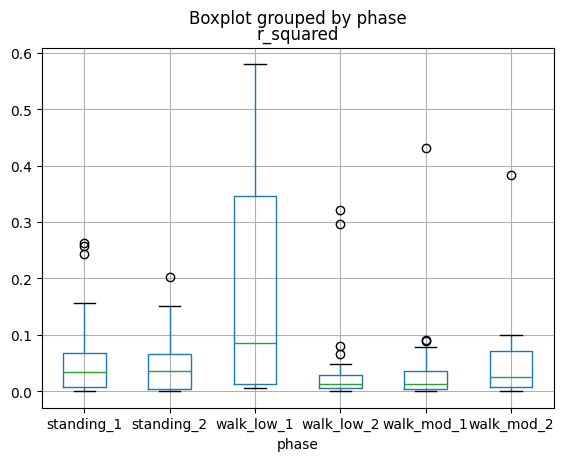

In [14]:
fit_df.groupby("phase")["r_squared"].describe()


fit_df.boxplot(
    column="r_squared",
    by="phase"
)

fit_df["good_fit"] = fit_df["r_squared"] > 0.20

fit_df.groupby("phase")["good_fit"].mean()


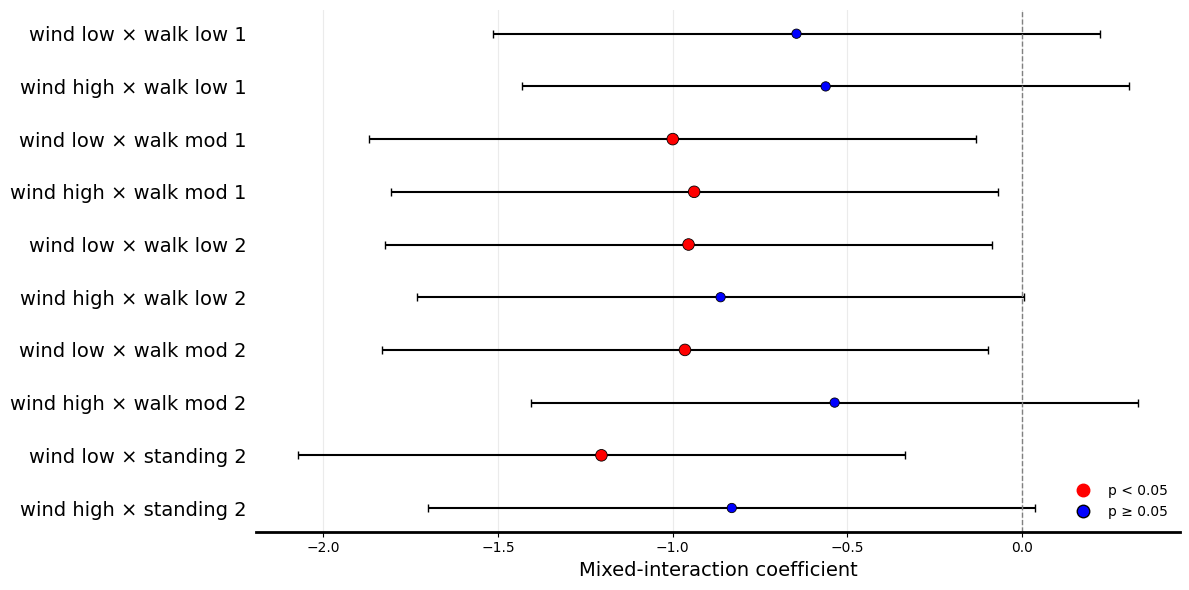

Saved: /home/eleonorab/repository/convective_cooling/reports/06_statistics/paper_figures/mixedlm_coefficients_forest_plot.png


In [15]:
coef_interactions_df = make_interaction_forest_plot(
    result=result,
    output_dir=FOREST_DIR,
)

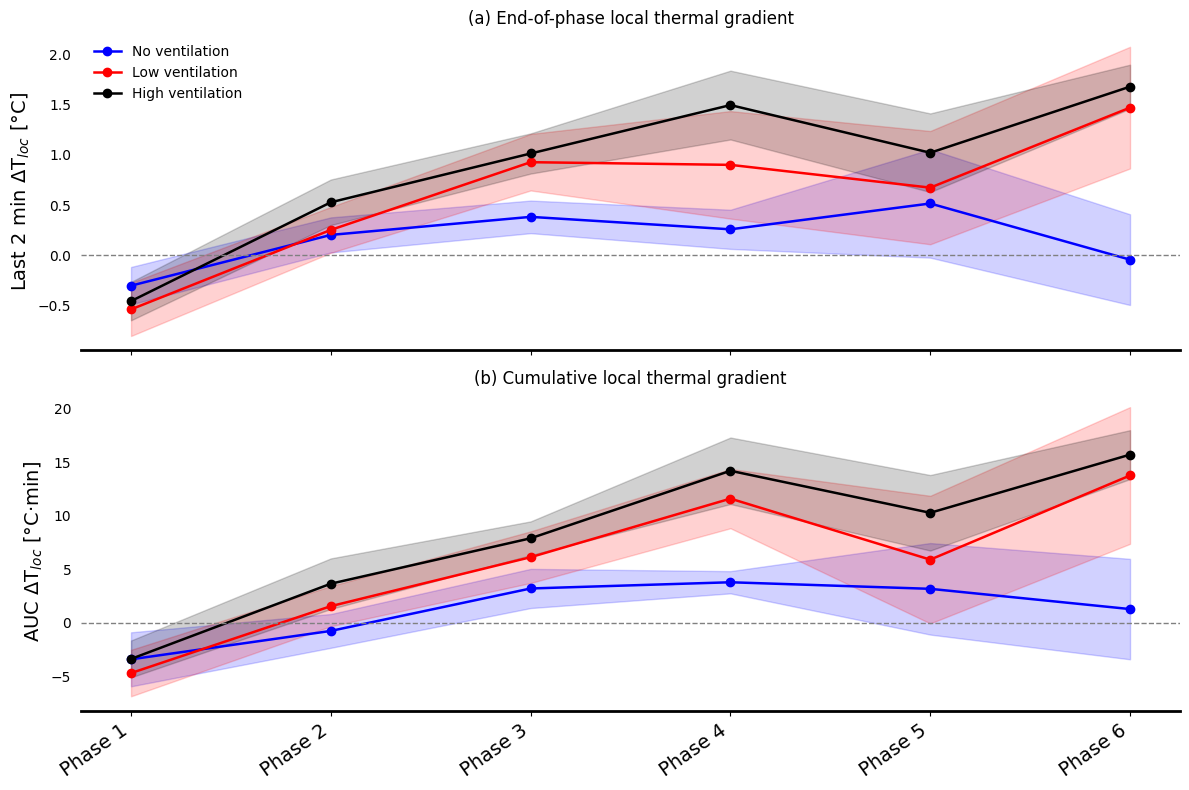

Saved: /home/eleonorab/repository/convective_cooling/reports/06_statistics/paper_figures/dynamic_phase_descriptors_main_figure.png


In [16]:
# ------------------------------------------------------------
# Main paper figure: dynamic phase descriptors
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DYNAMIC_FEATURES_FILE = (
    ROOT / "data" / "processed" / "features" / "dynamic_phase_features.csv"
)

FIG_DIR = ROOT / "reports" / "06_statistics" / "paper_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df_dyn = pd.read_csv(DYNAMIC_FEATURES_FILE)

signal_to_plot = "delta_t_loc"

plot_df = df_dyn[df_dyn["signal"] == signal_to_plot].copy()

phase_order = [
    "standing_1",
    "walk_low_1",
    "walk_mod_1",
    "walk_low_2",
    "walk_mod_2",
    "standing_2",
]

phase_labels = {
    "standing_1": "Phase 1",
    "walk_low_1": "Phase 2",
    "walk_mod_1": "Phase 3",
    "walk_low_2": "Phase 4",
    "walk_mod_2": "Phase 5",
    "standing_2": "Phase 6",
}

condition_order = ["no_wind", "wind_low", "wind_high"]

condition_labels = {
    "no_wind": "No ventilation",
    "wind_low": "Low ventilation",
    "wind_high": "High ventilation",
}

colors = {
    "no_wind": "blue",
    "wind_low": "red",
    "wind_high": "black",
}

plot_df["phase"] = pd.Categorical(
    plot_df["phase"],
    categories=phase_order,
    ordered=True,
)

plot_df["condition"] = pd.Categorical(
    plot_df["condition"],
    categories=condition_order,
    ordered=True,
)

summary = (
    plot_df
    .groupby(["condition", "phase"], observed=True)
    .agg(
        mean_value=("mean", "mean"),
        sem_value=("mean", lambda x: x.std(ddof=1) / np.sqrt(x.count())),
        late_value=("mean_last2min", "mean"),
        late_sem=("mean_last2min", lambda x: x.std(ddof=1) / np.sqrt(x.count())),
        auc_value=("auc", "mean"),
        auc_sem=("auc", lambda x: x.std(ddof=1) / np.sqrt(x.count())),
    )
    .reset_index()
)

x = np.arange(len(phase_order))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
)

panels = [
    (
        "late_value",
        "late_sem",
        "(a) End-of-phase local thermal gradient",
        "Last 2 min ΔT$_{loc}$ [°C]"
    ),
    (
        "auc_value",
        "auc_sem",
        "(b) Cumulative local thermal gradient",
        "AUC ΔT$_{loc}$ [°C·min]"
    ),
]

for ax, (value_col, sem_col, title, ylabel) in zip(axes, panels):
    for condition in condition_order:
        tmp = summary[summary["condition"] == condition].sort_values("phase")

        y = tmp[value_col].to_numpy()
        sem = tmp[sem_col].to_numpy()

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.8,
            label=condition_labels[condition],
            color=colors[condition],
        )

        ax.fill_between(
            x,
            y - sem,
            y + sem,
            alpha=0.18,
            color=colors[condition],
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_title(title)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [phase_labels[p] for p in phase_order],
        rotation=35,
        ha="right",
        fontsize=14,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.yaxis.set_ticks_position("none")
    ax.spines["bottom"].set_linewidth(2.0)

axes[0].legend(frameon=False, loc="best")

fig.tight_layout()

png_path = FIG_DIR / "dynamic_phase_descriptors_main_figure.png"

fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {png_path}")


In [17]:
# ============================================================
# TRANSITION COEFFICIENT k ANALYSIS
# T(t) = T_eq + (T0 - T_eq) exp(-k t)
# ============================================================

TRANSITION_DIR = ROOT / "reports" / "06_statistics" / "paper_figures"
TRANSITION_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_DIR = ROOT / "data" / "processed" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

transition_df = summary_df.copy()

transition_cols = [
    "k_transition_1_per_s",
    "tau_transition_s",
    "r_squared_transition",
]

for col in transition_cols:
    transition_df[col] = pd.to_numeric(transition_df[col], errors="coerce")

transition_df = transition_df.dropna(
    subset=["k_transition_1_per_s", "r_squared_transition"]
).copy()

transition_df = transition_df[
    transition_df["k_transition_1_per_s"] > 0
].copy()

transition_df["phase"] = pd.Categorical(
    transition_df["phase"],
    categories=PHASE_ORDER,
    ordered=True,
)

transition_df["condition"] = pd.Categorical(
    transition_df["condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

transition_summary = (
    transition_df
    .groupby(["phase", "condition"], observed=True)
    .agg(
        n=("k_transition_1_per_s", "count"),
        mean_k=("k_transition_1_per_s", "mean"),
        median_k=("k_transition_1_per_s", "median"),
        sd_k=("k_transition_1_per_s", "std"),
        mean_tau=("tau_transition_s", "mean"),
        median_tau=("tau_transition_s", "median"),
        mean_r2=("r_squared_transition", "mean"),
        median_r2=("r_squared_transition", "median"),
    )
    .reset_index()
)

transition_summary_path = FEATURES_DIR / "transition_k_summary.csv"
transition_summary.to_csv(transition_summary_path, index=False)

print(f"Saved: {transition_summary_path}")
display(transition_summary)

Saved: /home/eleonorab/repository/convective_cooling/data/processed/features/transition_k_summary.csv


,phase,condition,n,mean_k,median_k,sd_k,mean_tau,median_tau,mean_r2,median_r2
0,standing_1,no_wind,8,0.005644,0.004179,0.005801,2362.332948,240.286888,0.935177,0.942917
1,standing_1,wind_low,6,0.006418,0.007401,0.004417,476.924757,138.258812,0.892717,0.919374
2,standing_1,wind_high,7,0.004757,0.004725,0.003499,450.703921,211.643759,0.947187,0.977059
3,walk_low_1,no_wind,8,0.005801,0.000151,0.013211,9718.733336,6947.327686,0.873177,0.923094
4,walk_low_1,wind_low,6,0.007102,0.006252,0.002604,157.638513,161.148378,0.966644,0.992622
5,walk_low_1,wind_high,7,0.007279,0.008756,0.004053,2809.185480,114.202521,0.959256,0.993840
6,walk_mod_1,no_wind,8,0.016931,0.000694,0.036868,13883.061878,1440.680978,0.645188,0.679223
7,walk_mod_1,wind_low,6,0.004223,0.004273,0.003734,27308.512120,242.724891,-4.193461,0.341550
8,walk_mod_1,wind_high,7,0.024331,0.008333,0.026831,3761.574813,120.000000,-1.217477,0.543275
9,walk_low_2,no_wind,8,0.004918,0.002829,0.005893,9279.739851,478.827204,0.822987,0.895124


In [18]:
transition_df["good_transition_fit"] = (
    transition_df["r_squared_transition"] >= 0.50
)

transition_valid_df = transition_df[
    transition_df["good_transition_fit"]
].copy()


transition_valid_summary = (
    transition_valid_df
    .groupby(["phase", "condition"], observed=True)
    .agg(
        n=("k_transition_1_per_s", "count"),
        median_k=("k_transition_1_per_s", "median"),
        p25_k=("k_transition_1_per_s", lambda x: x.quantile(0.25)),
        p75_k=("k_transition_1_per_s", lambda x: x.quantile(0.75)),
        median_tau=("tau_transition_s", "median"),
        p25_tau=("tau_transition_s", lambda x: x.quantile(0.25)),
        p75_tau=("tau_transition_s", lambda x: x.quantile(0.75)),
        median_r2=("r_squared_transition", "median"),
    )
    .reset_index()
)

display(transition_valid_summary)


,phase,condition,n,median_k,p25_k,p75_k,median_tau,p25_tau,p75_tau,median_r2
0,standing_1,no_wind,8,0.004179,0.002075,0.007178,240.286888,145.115048,1456.926923,0.942917
1,standing_1,wind_low,6,0.007401,0.002930,0.009575,138.258812,104.897897,453.920175,0.919374
2,standing_1,wind_high,7,0.004725,0.001825,0.007040,211.643759,142.097017,548.368949,0.977059
3,walk_low_1,no_wind,8,0.000151,0.000067,0.003170,6947.327686,352.935185,15065.009110,0.923094
4,walk_low_1,wind_low,6,0.006252,0.005657,0.009039,161.148378,113.428984,176.777064,0.992622
5,walk_low_1,wind_high,7,0.008756,0.005798,0.009109,114.202521,109.854180,193.973532,0.993840
6,walk_mod_1,no_wind,5,0.000708,0.000681,0.002514,1411.913247,397.733862,1469.448709,0.815549
7,walk_mod_1,wind_low,3,0.003465,0.001791,0.004273,288.600121,242.724891,4397.191964,0.913650
8,walk_mod_1,wind_high,4,0.004009,0.000122,0.015948,3519.421321,101.480597,9961.552601,0.799521
9,walk_low_2,no_wind,7,0.004276,0.000791,0.009284,233.844682,125.685668,2868.749051,0.905342


In [19]:
print("Linear model")
print(fit_df["r_squared"].describe())

print("\nTransition model")
print(transition_df["r_squared_transition"].describe())

Linear model
count    1.260000e+02
mean     7.205821e-02
std      1.138530e-01
min      2.379280e-07
25%      6.563877e-03
50%      2.568867e-02
75%      7.500365e-02
max      5.806196e-01
Name: r_squared, dtype: float64

Transition model
count    126.000000
mean       0.383613
std        2.399161
min      -13.990251
25%        0.767841
50%        0.909330
75%        0.970016
max        0.998163
Name: r_squared_transition, dtype: float64
